<a href="https://colab.research.google.com/github/olkanth/MSCS_634_ProjectDeliverable_2/blob/main/MSCS_634_Project_Deliverable2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laxmi Kanth Oruganti
## MSCS-634 : Advanced Big Data and Data Mining
## Project Deliverable 2: Regression Modeling and Performance Evaluation

**University:** University of the Cumberlands  
**Dataset:** Framingham Heart Study  
**Source:** [Kaggle – aasheesh200/framingham-heart-study-dataset](https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset)


## 1. Introduction

In Deliverable 1, I performed data preprocessing on the Framingham Heart Study dataset — handling missing values via median/mode imputation, validating clinical value ranges using JNC 8 / WHO / ADA / AHA guidelines, applying two-step Winsorization (IQR detection + 1st–99th percentile capping via `pandas.Series.clip()`), and conducting exploratory data analysis across 8 visualizations.

In this deliverable, I focus on **regression modeling**. The Framingham dataset's primary outcome (`TenYearCHD`) is binary, so I selected **systolic blood pressure (`sysBP`)** as the continuous regression target. Predicting systolic blood pressure from demographic, behavioral, and clinical features is clinically meaningful — sysBP is one of the most important modifiable cardiovascular risk factors (AHA/ACC Hypertension Guidelines) — and well-suited for demonstrating regression techniques.

**Deliverable 2 Objectives:**
1. **Feature Engineering :** Engineer new features that capture clinical domain knowledge and non-linear relationships
2. **Regression :** Build and compare multiple regression models: Linear Regression, Ridge, Lasso, and Elastic Net
3. Evaluate models using R², Adjusted R², MSE, RMSE, and MAE
4. Use 10-fold cross-validation to assess generalization performance
5. Interpret results and identify the most predictive features for systolic blood pressure

## 2. Library Imports

In [89]:
# Import necessary libraries
import pandas as pd          # DataFrames — primary data structure throughout
import numpy as np           # Array math, quantile calculations, masking

import matplotlib.pyplot as plt   # Base plotting engine — used for all figures
import seaborn as sns             # High-level statistical plots (histplots, boxplots, heatmaps)

import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports for modeling and evaluation
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create the directory if it doesn't exist
import os
os.makedirs('Visualizations', exist_ok=True)

## 3. Load the Dataset

I load the same Framingham Heart Study dataset used in Deliverable 1. The CSV file is loaded from the local directory (uploaded via Colab).

In [90]:
# Upload dataset file (framingham.csv)
from google.colab import files

# uploaded = files.upload()
# uploaded

In [91]:
# -----------------------------------------------------------
# Load dataset and inspect
# Same dataset as Deliverable 1: 4,240 rows × 16 columns
# -----------------------------------------------------------
df = pd.read_csv('framingham.csv')
print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print('=' * 50)
df.info()
print('=' * 50)
df.head()

Dataset loaded successfully.
Shape: 4,240 rows × 16 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtype

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 4. Data Preprocessing (Replicated from Deliverable 1)

I apply the exact same preprocessing pipeline from Deliverable 1 to ensure consistency:
1. Median imputation for numeric columns, mode imputation for categorical/binary columns
2. Duplicate detection
3. Value range validation
4. Outlier detection (IQR) and treatment (1st–99th percentile Winsorization)

The working dataframe is `df_clean_data` — same variable name used throughout Deliverable 1.

In [92]:
# ------------------------------------------------------------------
# 4.1 Missing Value Imputation
# ------------------------------------------------------------------
# Copy the original dataframe to do all the clean up.
# Going forward, we will use the copied dataset
df_clean_data = df.copy()

# From the "Missing values analysis" cell in Deliverable 1,
# we can see below include numeric and non numeric has missing values
numeric_missing = ["glucose", "BPMeds", "totChol", "BMI", "heartRate", "cigsPerDay"]
#  Education is categorical data & BPMeds is binary data
non_numeric_missing = ["education", "BPMeds"]

print("Missing values before imputation:")
missing_before = df_clean_data.isnull().sum()
print(missing_before[missing_before > 0])
print(f"Total: {df_clean_data.isnull().sum().sum()}")
print()

# Replace missing values with the median in all numeric columns
for col in numeric_missing:
    median = df[col].median()
    df_clean_data[col].fillna(median, inplace=True)
    print(f"Imputed '{col}' with median value: {median}")

# Replace missing value with the mode in non numeric columns
for col in non_numeric_missing:
    mode = df[col].mode()[0]
    df_clean_data[col].fillna(mode, inplace=True)
    print(f"Imputed '{col}' with mode value: {mode}")

remaining = df_clean_data.isnull().sum().sum()
print("=" * 50)
print(f"Remaining missing values: {remaining}")

Missing values before imputation:
education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64
Total: 645

Imputed 'glucose' with median value: 78.0
Imputed 'BPMeds' with median value: 0.0
Imputed 'totChol' with median value: 234.0
Imputed 'BMI' with median value: 25.4
Imputed 'heartRate' with median value: 75.0
Imputed 'cigsPerDay' with median value: 0.0
Imputed 'education' with mode value: 1.0
Imputed 'BPMeds' with mode value: 0.0
Remaining missing values: 0


In [93]:
# ------------------------------------------------------------------
# 4.2 Duplicate Detection
# ------------------------------------------------------------------
duplicate_cnt = df_clean_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_cnt}")
if duplicate_cnt > 0:
    df_clean_data.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df_clean_data.shape}")
else:
    print("No duplicates found — no action needed.")

Number of duplicate rows: 0
No duplicates found — no action needed.


In [94]:
# -----------------------------------------------------------------
# 4.3 Outlier Detection & Treatment (Winsorization)
# Exact same logic from Deliverable 1
# -----------------------------------------------------------------

continuous_cols = ["totChol", "sysBP", "diaBP", "BMI", "glucose"]
discrete_num_cols = ["age", "cigsPerDay", "heartRate"]

# Combined for operations that apply equally to all numeric features
all_numeric_cols = continuous_cols + discrete_num_cols

# ── Step 1: Detect outliers (IQR method) ──
print("STEP 1 — OUTLIER DETECTION (IQR Method)")
print("=" * 65)

outlier_report = {}
for col in all_numeric_cols:
    Q1 = df_clean_data[col].quantile(0.25)
    Q3 = df_clean_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean_data[col] < lower) | (df_clean_data[col] > upper)).sum()
    pct = n_out / len(df_clean_data) * 100
    outlier_report[col] = n_out
    print(f"  {col:<15} | IQR fence: [{lower:6.1f}, {upper:6.1f}] "
          f"| Outliers: {n_out:>4} ({pct:.1f}%)")

print(f"\nTotal outlier instances detected: {sum(outlier_report.values()):,}")

# ── Step 2: Apply Winsorization (1st–99th percentile capping) ──
print("\nSTEP 2 — OUTLIER TREATMENT (1st–99th Percentile Capping)")
print("=" * 65)

for col in all_numeric_cols:
    p01 = df_clean_data[col].quantile(0.01)
    p99 = df_clean_data[col].quantile(0.99)
    n_low  = (df_clean_data[col] < p01).sum()
    n_high = (df_clean_data[col] > p99).sum()
    df_clean_data[col] = df_clean_data[col].clip(lower=p01, upper=p99)
    print(f"  {col:<15} | P1={p01:>7.2f}  P99={p99:>7.2f} | Capped: {n_low + n_high}")

print(f"\nPreprocessing complete. Working dataframe: df_clean_data")
print(f"Shape: {df_clean_data.shape}")

STEP 1 — OUTLIER DETECTION (IQR Method)
  totChol         | IQR fence: [ 122.0,  346.0] | Outliers:   57 (1.3%)
  sysBP           | IQR fence: [  76.5,  184.5] | Outliers:  126 (3.0%)
  diaBP           | IQR fence: [  52.5,  112.5] | Outliers:   77 (1.8%)
  BMI             | IQR fence: [  15.6,   35.5] | Outliers:   97 (2.3%)
  glucose         | IQR fence: [  52.5,  104.5] | Outliers:  262 (6.2%)
  age             | IQR fence: [  21.0,   77.0] | Outliers:    0 (0.0%)
  cigsPerDay      | IQR fence: [ -30.0,   50.0] | Outliers:   12 (0.3%)
  heartRate       | IQR fence: [  45.5,  105.5] | Outliers:   76 (1.8%)

Total outlier instances detected: 707

STEP 2 — OUTLIER TREATMENT (1st–99th Percentile Capping)
  totChol         | P1= 153.39  P99= 353.61 | Capped: 86
  sysBP           | P1=  97.00  P99= 200.00 | Capped: 81
  diaBP           | P1=  60.00  P99= 118.00 | Capped: 80
  BMI             | P1=  18.17  P99=  38.95 | Capped: 86
  glucose         | P1=  56.00  P99= 170.00 | Capped: 83
  

## 5. Feature Engineering

Feature engineering is critical for improving regression model performance. I create new features grounded in clinical domain knowledge and statistical reasoning.

In the Deliverable 1 README, I noted that `glucose` and `cigsPerDay` would need `log1p` transformation before regression modeling due to their heavy right skew. I apply that here along with two additional derived features.

**Engineered Features:**

| # | Feature | Description | Rationale |
|---|---------|-------------|-----------|
| 1 | `log_glucose` | log1p(glucose) | Heavy right skew (skew=2.52 in raw data); log transform normalizes distribution |
| 2 | `log_cigsPerDay` | log1p(cigsPerDay) | Extreme right skew (skew=1.14); large spike at 0 with long tail |
| 3 | `age_squared` | age² | Captures non-linear, accelerating relationship between age and blood pressure |
| 4 | `hypertension_risk_score` | Composite normalized score | Combines age, BMI, totChol, diabetes, and prevalentHyp into a single risk metric |

*Note: Since `sysBP` is the target variable, I do NOT create `pulse_pressure` (sysBP − diaBP) as a predictor — that would introduce data leakage. I also exclude `diaBP` from predictors because diastolic and systolic BP are correlated by definition — including diaBP would inflate model performance artificially.*

In [95]:
# ============================================================
# 5.1 Create Engineered Features
# ============================================================

# 1. Log-transformed glucose (addresses heavy right skew noted in Deliverable 1)
df_clean_data['log_glucose'] = np.log1p(df_clean_data['glucose'])
print(f"1. log_glucose — Mean: {df_clean_data['log_glucose'].mean():.4f}, "
      f"Std: {df_clean_data['log_glucose'].std():.4f}")

# 2. Log-transformed cigsPerDay (addresses right skew + zero-inflation)
df_clean_data['log_cigsPerDay'] = np.log1p(df_clean_data['cigsPerDay'])
print(f"2. log_cigsPerDay — Mean: {df_clean_data['log_cigsPerDay'].mean():.4f}, "
      f"Std: {df_clean_data['log_cigsPerDay'].std():.4f}")

# 3. Age Squared — captures non-linear age-BP relationship
df_clean_data['age_squared'] = df_clean_data['age'] ** 2
print(f"3. age_squared — Mean: {df_clean_data['age_squared'].mean():.2f}")

# 4. Hypertension Risk Score — composite of known risk factors
#    Each component is min-max normalized to [0, 1] before summing
df_clean_data['hypertension_risk_score'] = (
    (df_clean_data['age'] - df_clean_data['age'].min()) /
    (df_clean_data['age'].max() - df_clean_data['age'].min()) +
    (df_clean_data['BMI'] - df_clean_data['BMI'].min()) /
    (df_clean_data['BMI'].max() - df_clean_data['BMI'].min()) +
    (df_clean_data['totChol'] - df_clean_data['totChol'].min()) /
    (df_clean_data['totChol'].max() - df_clean_data['totChol'].min()) +
    df_clean_data['diabetes'] +
    df_clean_data['prevalentHyp']
)
print(f"4. hypertension_risk_score — Mean: {df_clean_data['hypertension_risk_score'].mean():.2f}, "
      f"Range: [{df_clean_data['hypertension_risk_score'].min():.2f}, "
      f"{df_clean_data['hypertension_risk_score'].max():.2f}]")

print(f"\nDataset shape after feature engineering: {df_clean_data.shape}")

1. log_glucose — Mean: 4.3887, Std: 0.1703
2. log_cigsPerDay — Mean: 1.3426, Std: 1.4654
3. age_squared — Mean: 2530.96
4. hypertension_risk_score — Mean: 1.57, Range: [0.07, 4.78]

Dataset shape after feature engineering: (4240, 20)


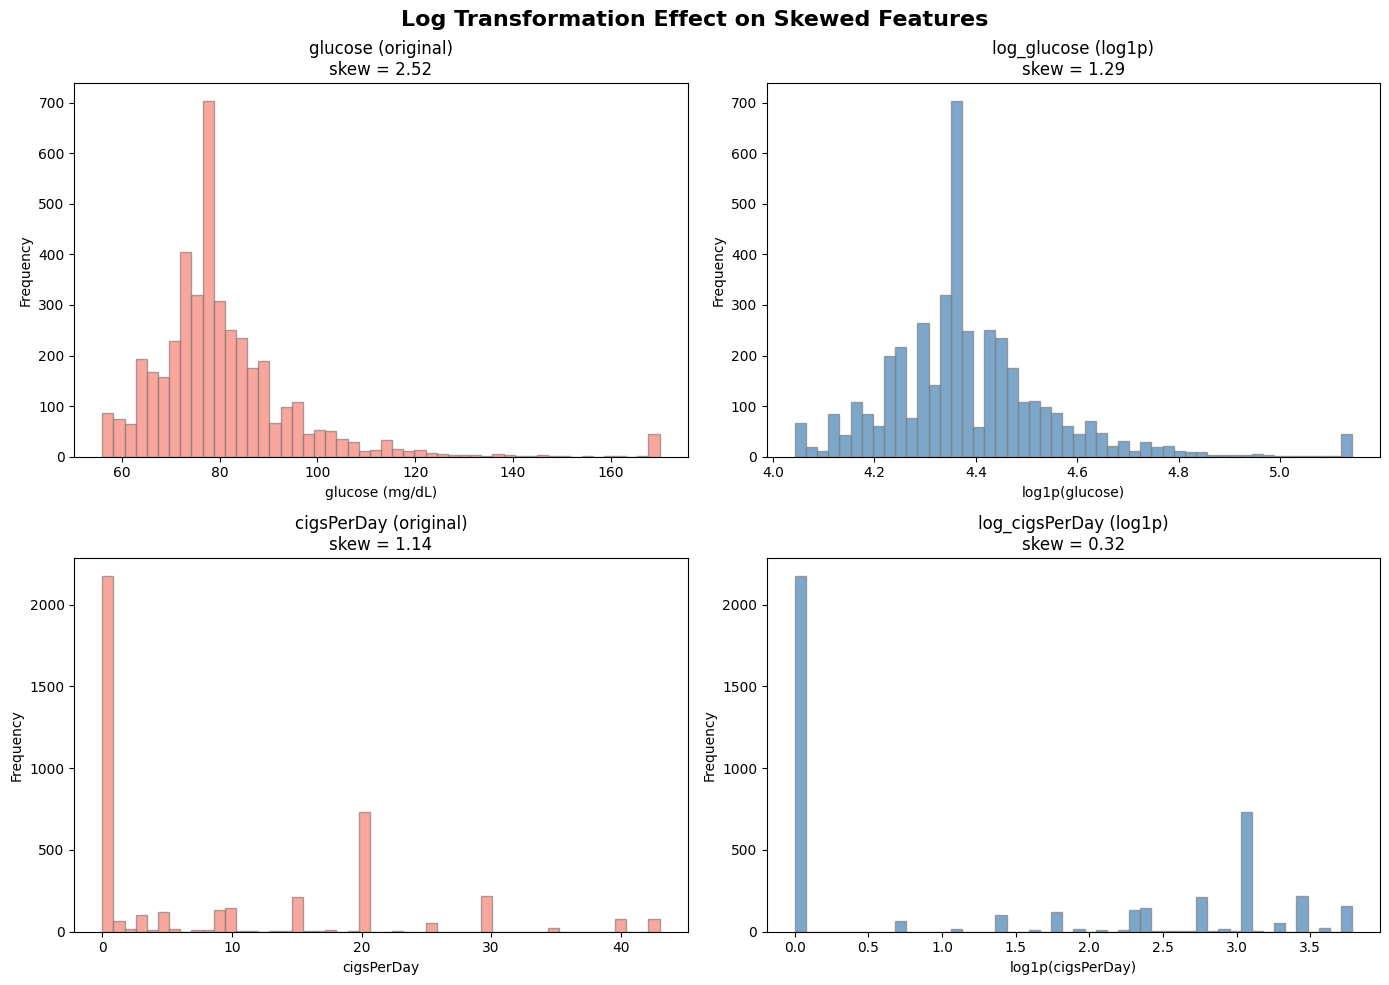

In [96]:
# ============================================================
# 5.2 Verify log transforms addressed the skewness
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Log Transformation Effect on Skewed Features', fontsize=16, fontweight='bold')

# glucose — before vs after
axes[0, 0].hist(df_clean_data['glucose'], bins=50, color='salmon', alpha=0.7, edgecolor='gray')
axes[0, 0].set_title(f"glucose (original)\nskew = {df_clean_data['glucose'].skew():.2f}")
axes[0, 0].set_xlabel('glucose (mg/dL)')

axes[0, 1].hist(df_clean_data['log_glucose'], bins=50, color='steelblue', alpha=0.7, edgecolor='gray')
axes[0, 1].set_title(f"log_glucose (log1p)\nskew = {df_clean_data['log_glucose'].skew():.2f}")
axes[0, 1].set_xlabel('log1p(glucose)')

# cigsPerDay — before vs after
axes[1, 0].hist(df_clean_data['cigsPerDay'], bins=50, color='salmon', alpha=0.7, edgecolor='gray')
axes[1, 0].set_title(f"cigsPerDay (original)\nskew = {df_clean_data['cigsPerDay'].skew():.2f}")
axes[1, 0].set_xlabel('cigsPerDay')

axes[1, 1].hist(df_clean_data['log_cigsPerDay'], bins=50, color='steelblue', alpha=0.7, edgecolor='gray')
axes[1, 1].set_title(f"log_cigsPerDay (log1p)\nskew = {df_clean_data['log_cigsPerDay'].skew():.2f}")
axes[1, 1].set_xlabel('log1p(cigsPerDay)')

for ax in axes.flat:
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('Visualizations/1_log_transform_skewness.png', dpi=150, bbox_inches='tight')
plt.show()

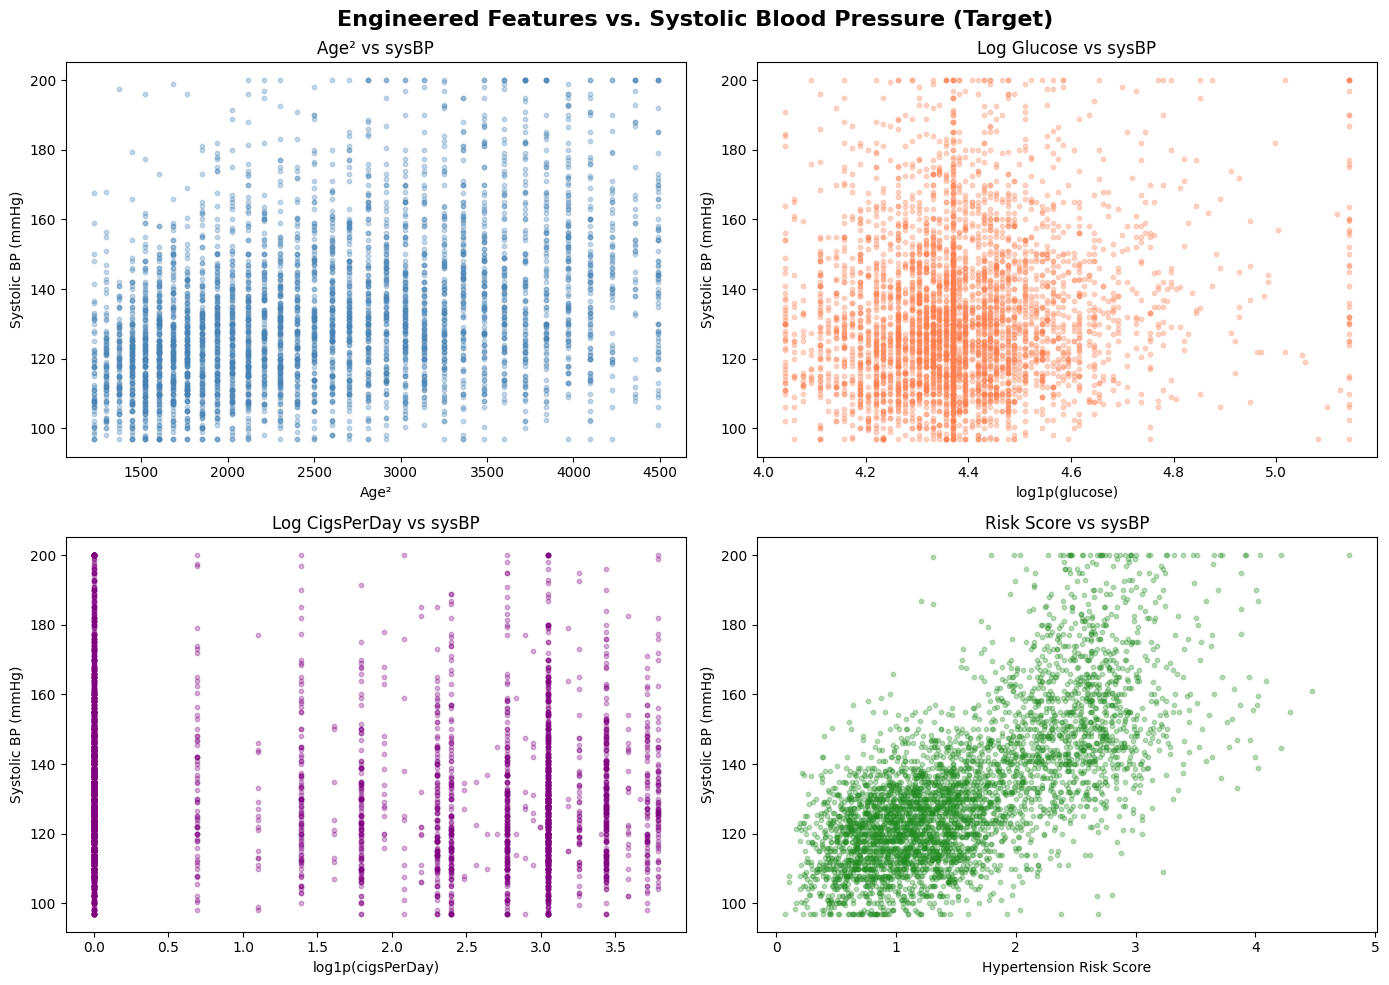

In [97]:
# ============================================================
# 5.3 Visualize Engineered Features vs Target (sysBP)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Engineered Features vs. Systolic Blood Pressure (Target)',
             fontsize=16, fontweight='bold')

# Age Squared vs sysBP
axes[0, 0].scatter(df_clean_data['age_squared'], df_clean_data['sysBP'],
                   alpha=0.3, s=10, color='steelblue')
axes[0, 0].set_xlabel('Age²')
axes[0, 0].set_ylabel('Systolic BP (mmHg)')
axes[0, 0].set_title('Age² vs sysBP')

# Log Glucose vs sysBP
axes[0, 1].scatter(df_clean_data['log_glucose'], df_clean_data['sysBP'],
                   alpha=0.3, s=10, color='coral')
axes[0, 1].set_xlabel('log1p(glucose)')
axes[0, 1].set_ylabel('Systolic BP (mmHg)')
axes[0, 1].set_title('Log Glucose vs sysBP')

# Log CigsPerDay vs sysBP
axes[1, 0].scatter(df_clean_data['log_cigsPerDay'], df_clean_data['sysBP'],
                   alpha=0.3, s=10, color='purple')
axes[1, 0].set_xlabel('log1p(cigsPerDay)')
axes[1, 0].set_ylabel('Systolic BP (mmHg)')
axes[1, 0].set_title('Log CigsPerDay vs sysBP')

# Hypertension Risk Score vs sysBP
axes[1, 1].scatter(df_clean_data['hypertension_risk_score'], df_clean_data['sysBP'],
                   alpha=0.3, s=10, color='forestgreen')
axes[1, 1].set_xlabel('Hypertension Risk Score')
axes[1, 1].set_ylabel('Systolic BP (mmHg)')
axes[1, 1].set_title('Risk Score vs sysBP')

plt.tight_layout()
plt.savefig('Visualizations/2_engineered_features_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Selection and Data Preparation

I define the predictor variables (X) and the target variable (y = `sysBP`), then split into training and test sets with standardization.

**Exclusions from predictor set:**
- `sysBP` — the target variable itself
- `diaBP` — highly correlated with sysBP by physiological definition; including it would inflate R² artificially
- `TenYearCHD` — binary outcome from a different prediction task; not a legitimate predictor of blood pressure
- `glucose` and `cigsPerDay` (originals) — replaced by their log-transformed versions

In [98]:
# ============================================================
# 6.1 Define Features and Target
# ============================================================
target = 'sysBP'
y = df_clean_data[target].copy()

# Exclude target, leaky/collinear features, and originals replaced by log versions
exclude_cols = ['sysBP', 'diaBP', 'TenYearCHD', 'glucose', 'cigsPerDay']
feature_cols = [col for col in df_clean_data.columns if col not in exclude_cols]

X = df_clean_data[feature_cols].copy()

print(f"Target variable: {target}")
print(f"Number of predictor features: {len(feature_cols)}")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")
print(f"\nTarget distribution:")
print(y.describe())

Target variable: sysBP
Number of predictor features: 15

Feature list:
   1. male
   2. age
   3. education
   4. currentSmoker
   5. BPMeds
   6. prevalentStroke
   7. prevalentHyp
   8. diabetes
   9. totChol
  10. BMI
  11. heartRate
  12. log_glucose
  13. log_cigsPerDay
  14. age_squared
  15. hypertension_risk_score

Target distribution:
count    4240.000000
mean      132.242217
std        21.409320
min        97.000000
25%       117.000000
50%       128.000000
75%       144.000000
max       200.000000
Name: sysBP, dtype: float64


In [99]:
# ============================================================
# 6.2 Train-Test Split (80/20, random_state=42)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining target — Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"Test target     — Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")

Training set: 3,392 samples (80.0%)
Test set:     848 samples (20.0%)

Training target — Mean: 132.34, Std: 21.61
Test target     — Mean: 131.85, Std: 20.61


In [100]:
# ============================================================
# 6.3 Feature Scaling (Standardization)
# ============================================================
# StandardScaler: zero mean, unit variance
# Important for regularized models (Ridge, Lasso) —
# coefficients penalized equally only if features are on the same scale.
# Fit on training data only; transform both train and test.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print("Feature scaling complete (StandardScaler).")
print(f"Training features: {X_train_scaled.shape}")
print(f"Test features:     {X_test_scaled.shape}")

Feature scaling complete (StandardScaler).
Training features: (3392, 15)
Test features:     (848, 15)


## 7. Correlation Analysis

Before modeling, I examine how each predictor correlates with the target variable `sysBP`. This validates the feature engineering decisions and sets expectations for model performance.

In [101]:
# ============================================================
# 7.1 Correlation with Target Variable
# ============================================================
correlations = X_train.corrwith(y_train).sort_values(ascending=False)

print("Feature correlations with sysBP (sorted by absolute value):")
print("=" * 55)
for feat, corr in correlations.abs().sort_values(ascending=False).items():
    direction = "+" if correlations[feat] > 0 else "-"
    print(f"  {feat:30s}  {direction}{corr:.4f}")

Feature correlations with sysBP (sorted by absolute value):
  prevalentHyp                    +0.7099
  hypertension_risk_score         +0.6991
  age                             +0.3977
  age_squared                     +0.3967
  BMI                             +0.3269
  BPMeds                          +0.2571
  totChol                         +0.1992
  heartRate                       +0.1939
  education                       -0.1338
  log_glucose                     +0.1295
  currentSmoker                   -0.1212
  diabetes                        +0.1149
  log_cigsPerDay                  -0.1143
  male                            -0.0509
  prevalentStroke                 +0.0428


## 8. Regression Model Building

I build and compare three regression models:

| Model | Description | Key Property |
|-------|-------------|-------------|
| **Linear Regression** | Ordinary Least Squares (OLS) — no regularization | Baseline model |
| **Ridge Regression** | L2 regularization — penalizes large coefficients | Handles multicollinearity |
| **Lasso Regression** | L1 regularization — can zero out coefficients | Built-in feature selection |

All models use the standardized features to ensure fair comparison, especially since regularized models are sensitive to feature scaling.

In [102]:
# ============================================================
# 8.1 Define Models
# ============================================================
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression (α=1.0)': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression (α=0.1)': Lasso(alpha=0.1, random_state=42, max_iter=10000)
}

print("Models to be trained:")
for i, (name, model) in enumerate(models.items(), 1):
    print(f"  {i}. {name}")

Models to be trained:
  1. Linear Regression
  2. Ridge Regression (α=1.0)
  3. Lasso Regression (α=0.1)


In [103]:
# ============================================================
# 8.2 Train All Models and Collect Evaluation Metrics
# ============================================================
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict on both sets
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Evaluation metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Adjusted R² (test set)
    n = X_test_scaled.shape[0]
    p = X_test_scaled.shape[1]
    adj_r2 = 1 - (1 - test_r2) * (n - 1) / (n - p - 1)

    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'adj_r2': adj_r2,
        'mse': test_mse,
        'rmse': test_rmse,
        'mae': test_mae,
        'y_test_pred': y_test_pred
    }

    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    print(f"  Train R²:      {train_r2:.4f}")
    print(f"  Test R²:       {test_r2:.4f}")
    print(f"  Adjusted R²:   {adj_r2:.4f}")
    print(f"  MSE:           {test_mse:.4f}")
    print(f"  RMSE:          {test_rmse:.4f}")
    print(f"  MAE:           {test_mae:.4f}")


  Linear Regression
  Train R²:      0.5666
  Test R²:       0.5392
  Adjusted R²:   0.5309
  MSE:           195.4455
  RMSE:          13.9802
  MAE:           10.6640

  Ridge Regression (α=1.0)
  Train R²:      0.5666
  Test R²:       0.5392
  Adjusted R²:   0.5309
  MSE:           195.4386
  RMSE:          13.9799
  MAE:           10.6638

  Lasso Regression (α=0.1)
  Train R²:      0.5663
  Test R²:       0.5411
  Adjusted R²:   0.5329
  MSE:           194.6328
  RMSE:          13.9511
  MAE:           10.6468


## 9. Model Evaluation and Comparison

### 9.1 Summary Comparison Table

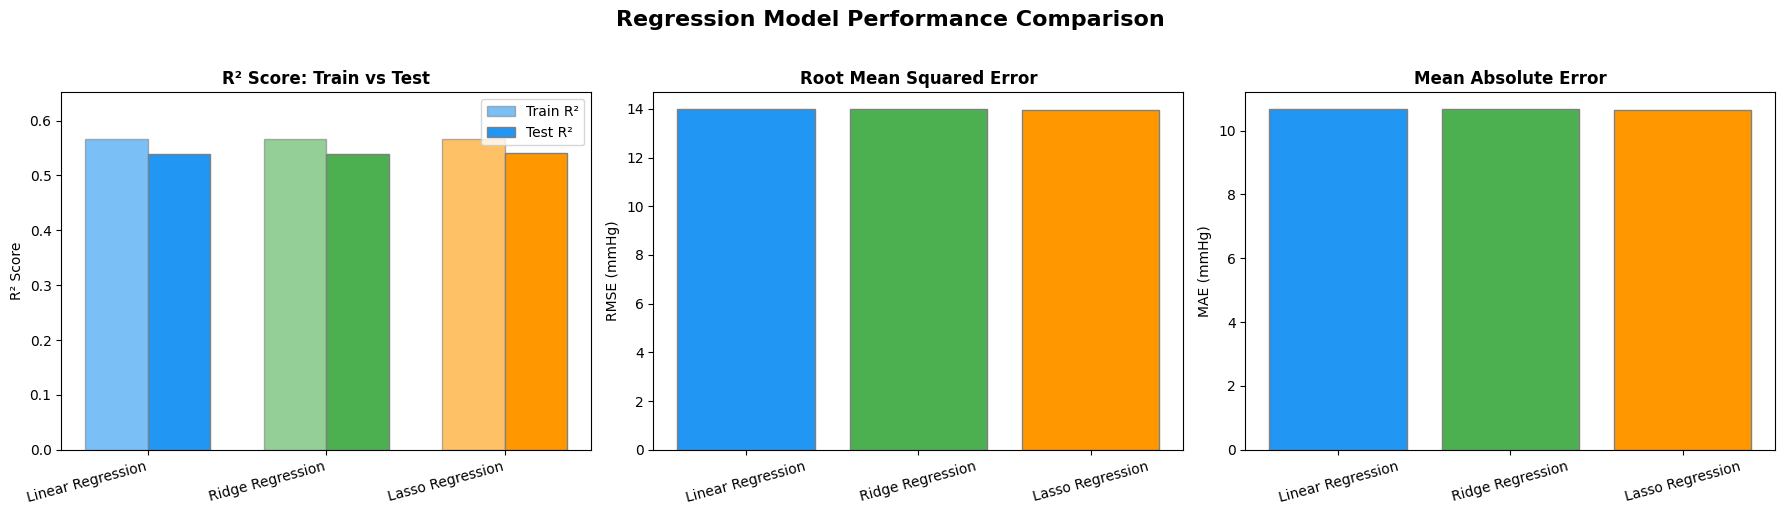

In [104]:
# ============================================================
# 9.2 Bar Chart — Model Performance Metrics
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names_short = [name.split('(')[0].strip() for name in results.keys()]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# R² Comparison (Train vs Test)
x = np.arange(len(model_names_short))
width = 0.35
axes[0].bar(x - width/2, [r['train_r2'] for r in results.values()], width,
            label='Train R²', color=colors, alpha=0.6, edgecolor='gray')
axes[0].bar(x + width/2, [r['test_r2'] for r in results.values()], width,
            label='Test R²', color=colors, alpha=1.0, edgecolor='gray')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score: Train vs Test', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names_short, rotation=15, ha='right')
axes[0].legend()
axes[0].set_ylim(0, max([r['train_r2'] for r in results.values()]) * 1.15)

# RMSE Comparison
axes[1].bar(model_names_short, [r['rmse'] for r in results.values()],
            color=colors, edgecolor='gray')
axes[1].set_ylabel('RMSE (mmHg)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

# MAE Comparison
axes[2].bar(model_names_short, [r['mae'] for r in results.values()],
            color=colors, edgecolor='gray')
axes[2].set_ylabel('MAE (mmHg)')
axes[2].set_title('Mean Absolute Error', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Regression Model Performance Comparison',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Visualizations/3_model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


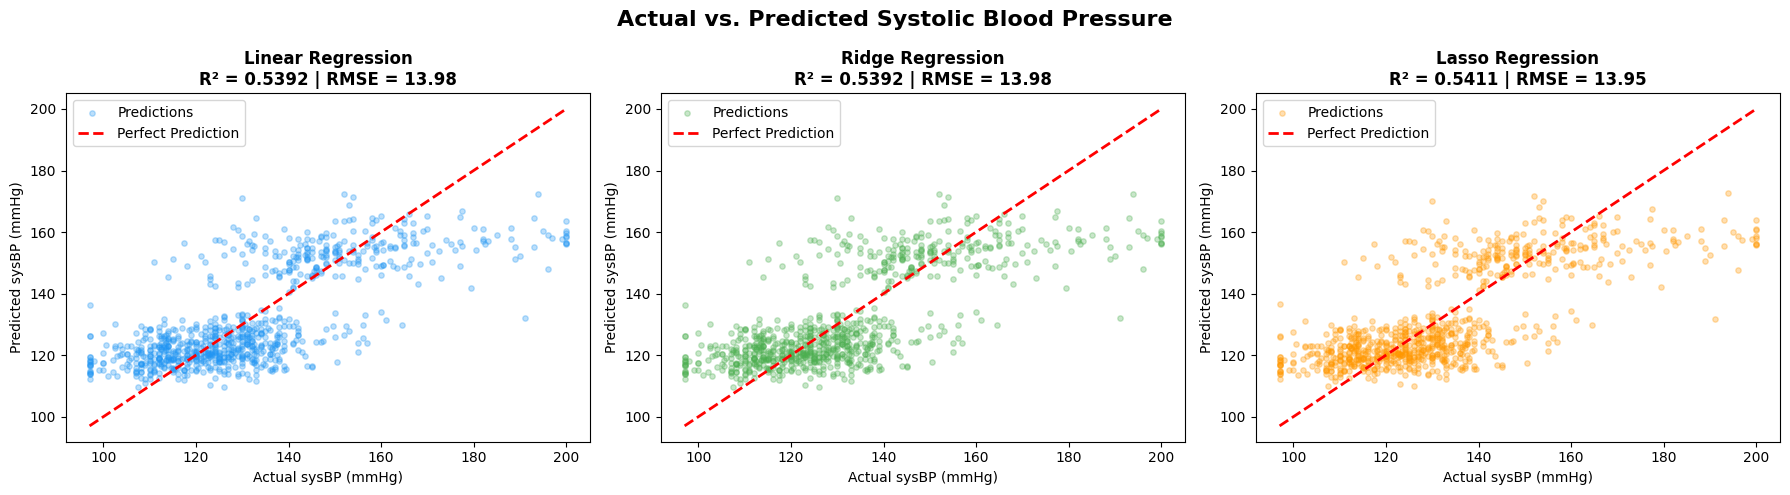

Figure saved: Visualizations/4_actual_vs_predicted.png


In [105]:
# ============================================================
# 9.3 Actual vs Predicted Scatter Plots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes_flat = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    ax = axes_flat[i]
    short_name = name.split('(')[0].strip()

    ax.scatter(y_test, res['y_test_pred'], alpha=0.3, s=15, color=colors[i],
               label='Predictions')

    # Perfect prediction line
    min_val = min(y_test.min(), res['y_test_pred'].min())
    max_val = max(y_test.max(), res['y_test_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
            label='Perfect Prediction')

    ax.set_xlabel('Actual sysBP (mmHg)')
    ax.set_ylabel('Predicted sysBP (mmHg)')
    ax.set_title(f'{short_name}\nR² = {res["test_r2"]:.4f} | RMSE = {res["rmse"]:.2f}',
                 fontweight='bold')
    ax.legend(loc='upper left')

plt.suptitle('Actual vs. Predicted Systolic Blood Pressure',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('Visualizations/4_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: Visualizations/4_actual_vs_predicted.png")

## 10. Cross-Validation

I use **10-fold cross-validation** to assess each model's ability to generalize to unseen data. Cross-validation provides a more robust performance estimate than a single train-test split by evaluating the model across 10 different data partitions — each fold serves as a held-out test set exactly once.

In [106]:
# ============================================================
# 10.1 K-Fold Cross-Validation (k=10)
# ============================================================
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Scale the full dataset for cross-validation
X_full_scaled = StandardScaler().fit_transform(X)
y_full = y.values

cv_results = {}

print("10-Fold Cross-Validation Results")
print("=" * 75)
print(f"  {'Model':<35} {'Mean R²':>10} {'Std R²':>10} {'Mean RMSE':>12} {'Std RMSE':>10}")
print("  " + "-" * 72)

for name, model_template in models.items():
    # R² scores across 10 folds
    r2_scores = cross_val_score(model_template, X_full_scaled, y_full,
                                cv=kf, scoring='r2')

    # RMSE scores (sklearn returns neg_MSE; convert to RMSE)
    neg_mse_scores = cross_val_score(model_template, X_full_scaled, y_full,
                                     cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-neg_mse_scores)

    cv_results[name] = {
        'r2_scores': r2_scores,
        'r2_mean': r2_scores.mean(),
        'r2_std': r2_scores.std(),
        'rmse_scores': rmse_scores,
        'rmse_mean': rmse_scores.mean(),
        'rmse_std': rmse_scores.std()
    }

    short_name = name.split('(')[0].strip()
    print(f"  {short_name:<35} {r2_scores.mean():>10.4f} {r2_scores.std():>10.4f} "
          f"{rmse_scores.mean():>12.4f} {rmse_scores.std():>10.4f}")

print("  " + "-" * 72)
best_cv = max(cv_results.items(), key=lambda x: x[1]['r2_mean'])
print(f"\n  Best CV model: {best_cv[0].split('(')[0].strip()} "
      f"(Mean R² = {best_cv[1]['r2_mean']:.4f} ± {best_cv[1]['r2_std']:.4f})")

10-Fold Cross-Validation Results
  Model                                  Mean R²     Std R²    Mean RMSE   Std RMSE
  ------------------------------------------------------------------------
  Linear Regression                       0.5564     0.0320      14.2161     0.2772
  Ridge Regression                        0.5565     0.0320      14.2158     0.2771
  Lasso Regression                        0.5567     0.0310      14.2137     0.2762
  ------------------------------------------------------------------------

  Best CV model: Lasso Regression (Mean R² = 0.5567 ± 0.0310)


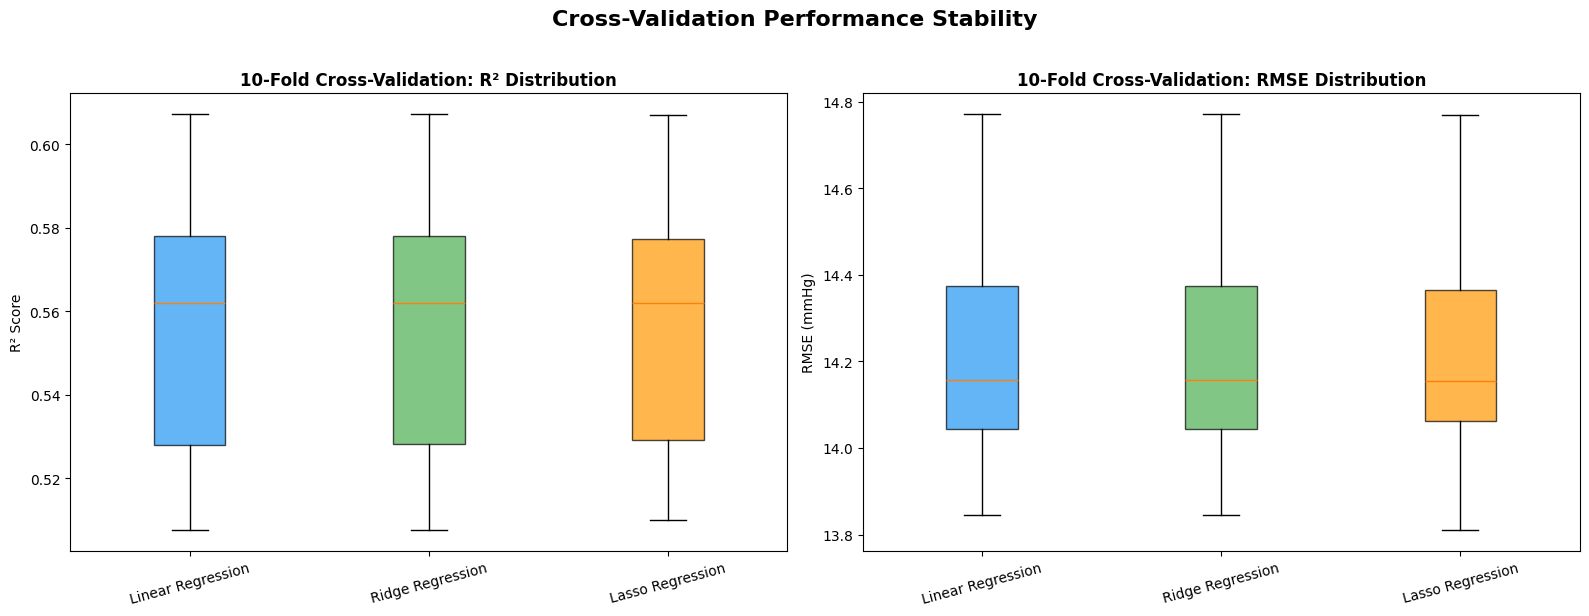

In [107]:
# ============================================================
# 10.2 Cross-Validation Box Plots
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_short_names = [name.split('(')[0].strip() for name in cv_results.keys()]

# R² Box Plot
r2_data = [cv['r2_scores'] for cv in cv_results.values()]
bp1 = axes[0].boxplot(r2_data, labels=model_short_names, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('R² Score')
axes[0].set_title('10-Fold Cross-Validation: R² Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# RMSE Box Plot
rmse_data = [cv['rmse_scores'] for cv in cv_results.values()]
bp2 = axes[1].boxplot(rmse_data, labels=model_short_names, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('RMSE (mmHg)')
axes[1].set_title('10-Fold Cross-Validation: RMSE Distribution', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Cross-Validation Performance Stability',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Visualizations/5_cross_validation_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Feature Importance Analysis

I examine the standardized regression coefficients across all four models. Since all features were standardized before fitting, the coefficients are directly comparable — larger absolute values indicate stronger contributions to predicting sysBP. For Lasso, coefficients driven to exactly zero indicate features that Lasso eliminated during its built-in feature selection.

In [108]:
# ============================================================
# 11.1 Feature Coefficients Comparison Table
# ============================================================
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Linear': results['Linear Regression']['model'].coef_,
    'Ridge': results['Ridge Regression (α=1.0)']['model'].coef_,
    'Lasso': results['Lasso Regression (α=0.1)']['model'].coef_
})

# Sort by absolute value of Linear Regression coefficients
coef_df['abs_linear'] = coef_df['Linear'].abs()
coef_df = coef_df.sort_values('abs_linear', ascending=False).drop('abs_linear', axis=1)

print("Feature Coefficients (Standardized — sorted by |Linear| coefficient)")
print("=" * 85)
print(coef_df.to_string(index=False, float_format='{:.4f}'.format))

# Lasso feature selection summary
lasso_selected = (coef_df['Lasso'] != 0).sum()
lasso_zeroed = (coef_df['Lasso'] == 0).sum()
print(f"\nLasso feature selection: {lasso_selected} features retained, "
      f"{lasso_zeroed} features zeroed out")
if lasso_zeroed > 0:
    zeroed_feats = coef_df[coef_df['Lasso'] == 0]['Feature'].tolist()
    print(f"  Zeroed features: {zeroed_feats}")

Feature Coefficients (Standardized — sorted by |Linear| coefficient)
                Feature  Linear   Ridge   Lasso
           prevalentHyp  9.2199  9.2258 10.8006
hypertension_risk_score  5.7687  5.7530  2.9893
                    age  1.7805  1.7133  2.4911
              heartRate  1.7513  1.7512  1.6986
                 BPMeds  1.4622  1.4623  1.3761
               diabetes -0.8746 -0.8708 -0.1049
                    BMI  0.8439  0.8483  1.4119
                totChol -0.7711 -0.7656  0.0000
                   male -0.7373 -0.7371 -0.6055
              education -0.7313 -0.7311 -0.6587
            log_glucose  0.5946  0.5944  0.4217
          currentSmoker  0.1461  0.1457  0.0000
        prevalentStroke -0.1149 -0.1148 -0.0041
            age_squared  0.0734  0.1462  0.1912
         log_cigsPerDay  0.0133  0.0138  0.0000

Lasso feature selection: 12 features retained, 3 features zeroed out
  Zeroed features: ['totChol', 'currentSmoker', 'log_cigsPerDay']


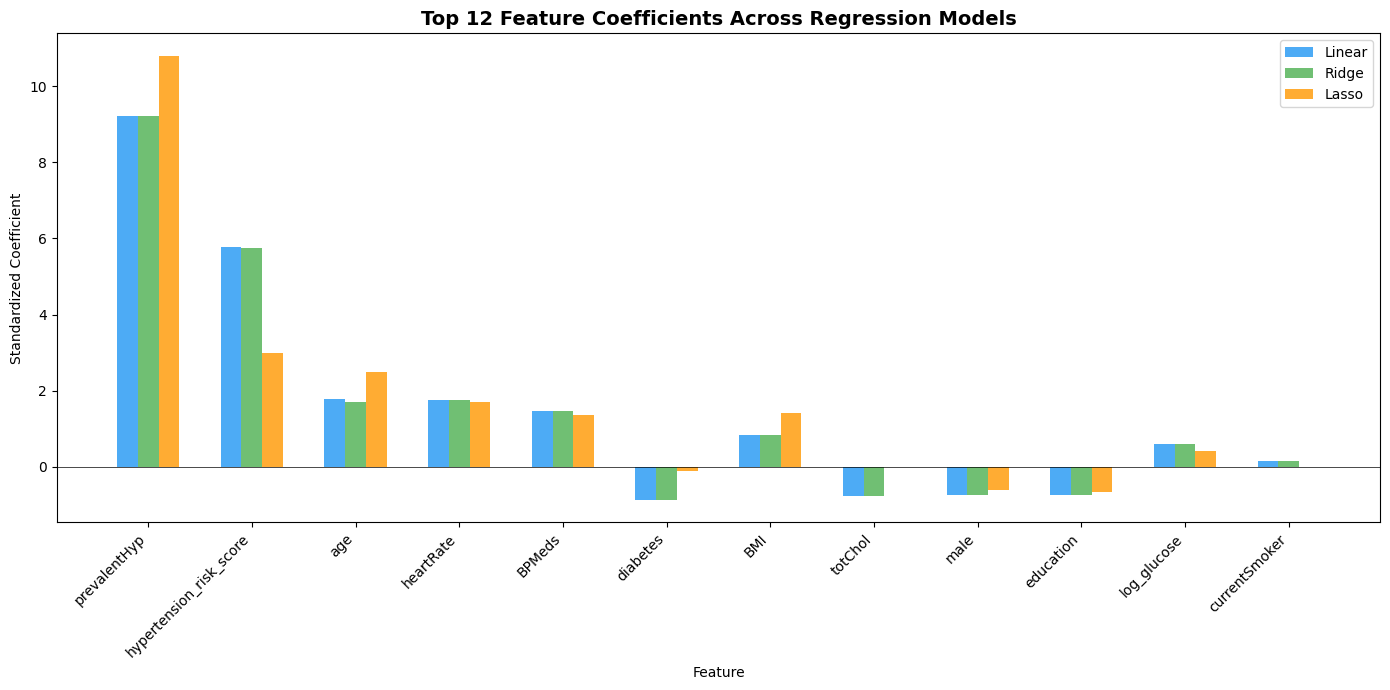

In [109]:
# ============================================================
# 11.2 Top Feature Importance Bar Chart
# ============================================================
top_n = 12
coef_plot = coef_df.head(top_n).copy()

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(coef_plot))
width = 0.2

ax.bar(x - width, coef_plot['Linear'], width, label='Linear',
       color=colors[0], alpha=0.8)
ax.bar(x, coef_plot['Ridge'], width, label='Ridge',
       color=colors[1], alpha=0.8)
ax.bar(x + width, coef_plot['Lasso'], width, label='Lasso',
       color=colors[2], alpha=0.8)

ax.set_xlabel('Feature')
ax.set_ylabel('Standardized Coefficient')
ax.set_title(f'Top {top_n} Feature Coefficients Across Regression Models',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(coef_plot['Feature'], rotation=45, ha='right')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('Visualizations/6_feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Regularization Analysis

I explore how the regularization strength (alpha) affects cross-validated R² for Ridge and Lasso. This visualizes the bias-variance trade-off: too little regularization risks overfitting, too much underfits by shrinking all coefficients toward zero.

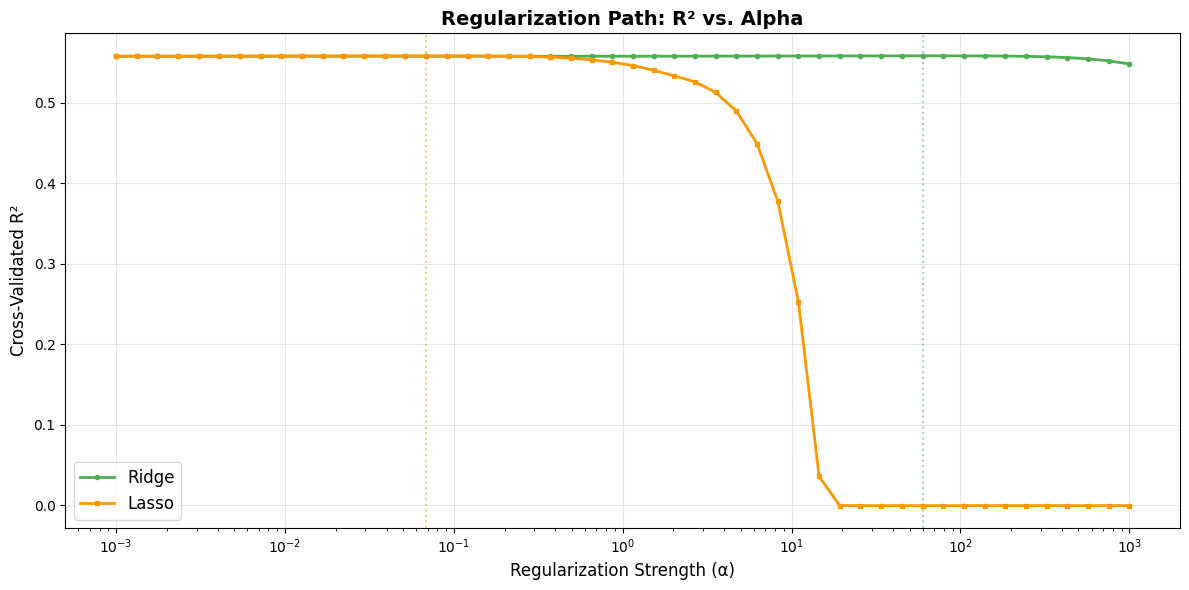

Optimal alpha — Ridge: 59.6362, Lasso: 0.0687


In [110]:
# ============================================================
# 12.1 Regularization Path — R² vs Alpha
# ============================================================
alphas = np.logspace(-3, 3, 50)

ridge_scores = []
lasso_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge_cv = cross_val_score(ridge, X_full_scaled, y_full, cv=5, scoring='r2')
    ridge_scores.append(ridge_cv.mean())

    lasso = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    lasso_cv = cross_val_score(lasso, X_full_scaled, y_full, cv=5, scoring='r2')
    lasso_scores.append(lasso_cv.mean())


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(alphas, ridge_scores, '-o', markersize=3, label='Ridge',
        color=colors[1], linewidth=2)
ax.plot(alphas, lasso_scores, '-s', markersize=3, label='Lasso',
        color=colors[2], linewidth=2)

ax.set_xscale('log')
ax.set_xlabel('Regularization Strength (α)', fontsize=12)
ax.set_ylabel('Cross-Validated R²', fontsize=12)
ax.set_title('Regularization Path: R² vs. Alpha', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Mark optimal alpha for each
best_ridge_alpha = alphas[np.argmax(ridge_scores)]
best_lasso_alpha = alphas[np.argmax(lasso_scores)]
ax.axvline(x=best_ridge_alpha, color=colors[1], linestyle=':', alpha=0.5)
ax.axvline(x=best_lasso_alpha, color=colors[2], linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('Visualizations/7_regularization_path.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Optimal alpha — Ridge: {best_ridge_alpha:.4f}, "
      f"Lasso: {best_lasso_alpha:.4f}")
